In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 38.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=88f6fbb720ec2d99dec16ac15b218c39201155c08b2a542b501743f68c5384c7
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


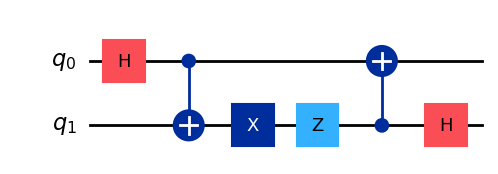

In [2]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing

# For 01, apply X to qubit 1
#sdc.x(1)

# For 10, apply Z to qubit 1
#sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [3]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [ ]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

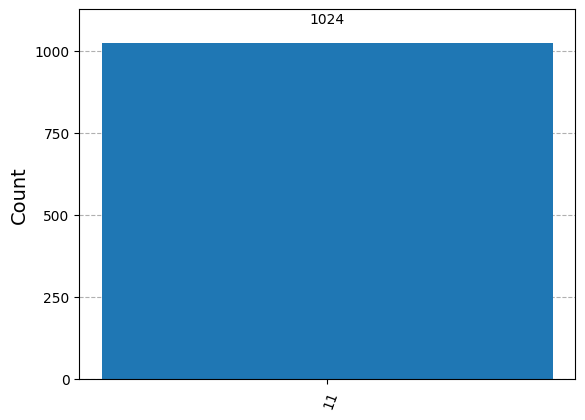

In [4]:
sdc.measure_all()

backend = BasicSimulator()

compiled = transpile(sdc, backend)

job_sim = backend.run(compiled, shots=1024)

result_sim = job_sim.result()

counts = result_sim.get_counts(compiled)

plot_histogram(counts)

In [ ]:
# EXERCISE

# A better implementation of superdense coding uses two classical bits as inputs,
# and the conditional operators that we saw in Lab-2B. Encoding the two-bit
# classical value is similar to the last stage of teleportation, where the measurement
# results are used to adjust Bob's qubit.

# Implement superdense coding this way.

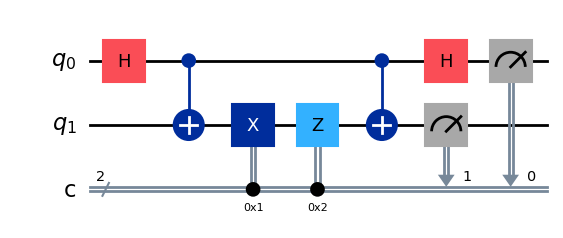

In [5]:
sdc2 = QuantumCircuit(2,2)

# Shared entangled pair
sdc2.h(0)
sdc2.cx(0,1)

# Classical bits
sdc2.x(1).c_if(sdc2.cregs[0],1)
sdc2.z(1).c_if(sdc2.cregs[0],2)

# Decode
sdc2.cx(0,1)
sdc2.h(0)

# Measure
sdc2.measure([0,1],[0,1])

sdc2.draw("mpl")